# Задача сегментации с использованием U-Net

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vpapenko/nails-segmentation")

print("Path to dataset files:", path)

/Users/albertzagibin/Documents/University/ML/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/albertzagibin/.cache/kagglehub/datasets/vpapenko/nails-segmentation/versions/1


In [2]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score
import glob
import tensorflow as tf
from tensorflow.keras import models, layers, Sequential
from tensorflow.keras.layers import Flatten, Dense, Reshape
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.preprocessing.image import img_to_array, load_img

## Функции для отображения результатов

In [3]:
def plot_image_and_mask(images, masks, image_paths):
    plt.figure(figsize=(20, 6))

    for i in range(5):
        idx = np.random.randint(len(images))
        plt.subplot(3, 8, i + 1)
        plt.imshow(images[idx], cmap="gray")
        plt.axis("off")
        plt.title(image_paths[idx].split("/")[-1])

        plt.subplot(3, 8, i + 9)
        plt.imshow(masks[idx], cmap="gray")
        plt.axis("off")
        plt.title("Mask")

    plt.show()


In [4]:
def plot_predictions(X_test, y_test, preds):
    plt.figure(figsize=(20, 6))

    for i in range(6):
        idx = np.random.randint(len(preds))
        plt.subplot(3, 8, i + 1)
        plt.imshow(X_test[idx], cmap="gray")
        plt.axis("off")
        plt.title("Image")

        plt.subplot(3, 8, i + 9)
        plt.imshow(y_test[idx], cmap="gray")
        plt.axis("off")
        plt.title("Original Mask")

        plt.subplot(3, 8, i + 17)
        plt.imshow(preds[idx], cmap="gray")
        plt.axis("off")
        plt.title("Predicted Mask")

    plt.show()

In [5]:
def plot_training_history(history, title="Training History"):
    metrics = [m for m in history.history.keys() if not m.startswith('val_')]
    n_metrics = len(metrics)
    
    n_cols = 2
    n_rows = (n_metrics + 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
    axes = axes.flatten() 
    fig.suptitle(title, fontsize=16)

    for i, metric in enumerate(metrics):
        ax = axes[i]
        ax.plot(history.history[metric], label=f"train {metric}")

        val_metric = f"val_{metric}"
        if val_metric in history.history:
            ax.plot(history.history[val_metric], label=f"val {metric}")
        
        ax.set_xlabel("Epoch")
        ax.set_ylabel(metric.capitalize())
        ax.set_title(f"Training vs Validation {metric.capitalize()}")
        ax.legend()
        ax.grid(True)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


## Подготовка данных

In [6]:
folders = os.listdir(path)
folders

['.DS_Store', 'images', 'nails_segmentation', 'labels']

In [7]:
image_paths = glob.glob(path+'/images/*')
mask_paths = glob.glob(path+'/labels/*')

In [8]:
def load_image(path):
    img = load_img(path, target_size=(128, 128), color_mode='grayscale')
    image_array = img_to_array(img)
    image_array /= 255.
    return image_array

In [9]:
images = []
masks = []

for image_path, mask_path in tqdm(zip(image_paths, mask_paths)):
    image = load_image(image_path)
    images.append(image)

    mask = load_image(mask_path)
    masks.append(mask)

52it [00:00, 133.85it/s]


In [10]:
images = np.array(images)
masks = np.array(masks)

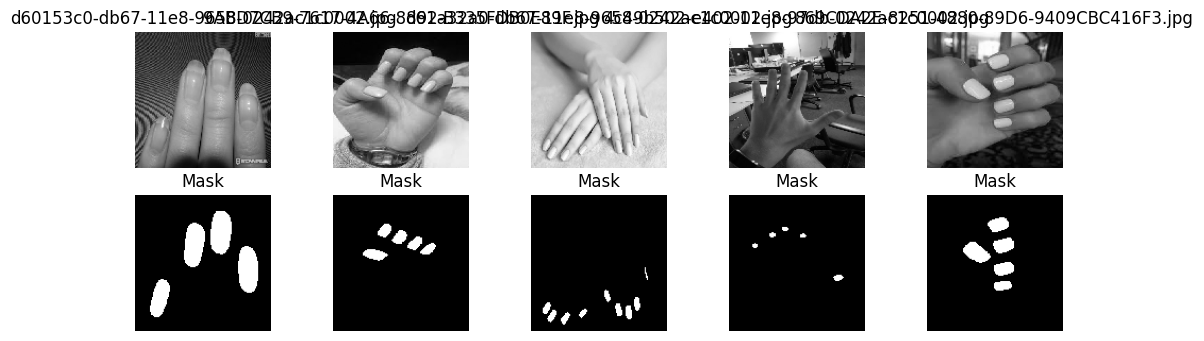

In [11]:
plot_image_and_mask(images, masks, image_paths)

In [12]:
X_train, X_temp, y_train, y_temp = train_test_split(images, masks, test_size=0.2, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)


## Baseline - Полносвязанная нейронная сеть

In [13]:
input_shape = (128, 128, 1)
output_shape = (128, 128, 1)

sequential_model = Sequential([
    Flatten(input_shape=input_shape),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(np.prod(output_shape), activation='sigmoid'),
    Reshape(output_shape)
])

sequential_model.compile(
    optimizer='adam', 
    loss='binary_crossentropy', 
    metrics=['accuracy', Precision(), Recall()]
)
sequential_model.summary()

/Users/albertzagibin/Documents/University/ML/venv/lib/python3.13/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16384)          │     2,113,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 128, 128, 1)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,666,880 (40.69 MB)

 Trainable params: 10,666,880 (40.69 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
sequential_history = sequential_model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 201ms/step - accuracy: 0.5280 - loss: 0.6858 - precision: 0.0547 - recall: 0.4779 - val_accuracy: 0.7904 - val_loss: 0.4964 - val_precision: 0.0284 - val_recall: 0.2089
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7949 - loss: 0.4850 - precision: 0.0538 - recall: 0.1699 - val_accuracy: 0.9503 - val_loss: 0.2172 - val_precision: 0.0268 - val_recall: 0.0250
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9284 - loss: 0.3024 - precision: 0.0589 - recall: 0.0223 - val_accuracy: 0.9726 - val_loss: 0.1814 - val_precision: 0.0549 - val_recall: 0.0023
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9455 - loss: 0.2363 - precision: 0.1543 - recall: 0.0035 - val_accuracy: 0.9663 - val_loss: 0.1979 - val_precision: 0.0209 - val_recall: 0.0060
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9414 - loss: 0.2192 - precision: 0.1870 - recall: 0.0277 - val_accuracy: 0.9689 - val_loss: 0.2090 - val_pre

## Реализация U-Net

In [15]:
def conv_block(inputs, num_filters):
    x = layers.Conv2D(num_filters, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.Conv2D(num_filters, (3, 3), activation='relu', padding='same')(x)
    return x


In [16]:
def encoder_block(inputs, num_filters):
    x = conv_block(inputs, num_filters)
    p = layers.MaxPooling2D((2, 2))(x)
    return x, p


In [17]:
def decoder_block(inputs, skip_features, num_filters):
    x = layers.Conv2DTranspose(num_filters, (2, 2), strides=(2, 2), padding='same')(inputs)
    x = layers.concatenate([x, skip_features])
    x = conv_block(x, num_filters)
    return x

In [18]:
def build_unet(input_shape=(128, 128, 1), num_classes=1):
    inputs = layers.Input(shape=input_shape)

    # --- Encoder ---
    s1, p1 = encoder_block(inputs, 64)
    s2, p2 = encoder_block(p1, 128)
    s3, p3 = encoder_block(p2, 256)
    s4, p4 = encoder_block(p3, 512)

    # --- Bottleneck ---
    b1 = conv_block(p4, 1024)

    # --- Decoder ---
    d1 = decoder_block(b1, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)

    # --- Output ---
    outputs = layers.Conv2D(num_classes, (1, 1), activation='sigmoid')(d4)

    model = models.Model(inputs, outputs, name="U-Net")

    return model

In [19]:
unet_model = build_unet(input_shape=(128, 128, 1), num_classes=1)
unet_model.compile(
    optimizer='adam', 
    loss='binary_crossentropy', 
    metrics=['accuracy', Precision(), Recall()]
)
unet_model.summary()

Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        640 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 8, 8, 512) │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 8, 8,      │  4,719,616 │ max_pooling2d_3[… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 8, 8,      │  9,438,208 │ conv2d_8[0][0]    │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 16, 16,    │  2,097,664 │ conv2d_9[0][0]    │
│ (Conv2DTranspose)   │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ conv2d_transpose

 Total params: 31,030,593 (118.37 MB)

 Trainable params: 31,030,593 (118.37 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
unet_history = unet_model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.8356 - loss: 0.6827 - precision_1: 0.0416 - recall_1: 0.0934 - val_accuracy: 0.9736 - val_loss: 0.5599 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.9464 - loss: 0.5199 - precision_1: 0.0000e+00 - recall_1: 0.0000e+00 - val_accuracy: 0.9736 - val_loss: 2.9201 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.9464 - loss: 5.2898 - precision_1: 0.0000e+00 - recall_1: 0.0000e+00 - val_accuracy: 0.9736 - val_loss: 0.3485 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.9464 - loss: 0.4072 - precision_1: 0.0000e+00 - recall_1: 0.0000e+00 - val_accuracy: 0.9736 - val_loss: 0.4621 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.9464 - loss: 0.4927 - precisio

## Сравнение результатов

### Baseline

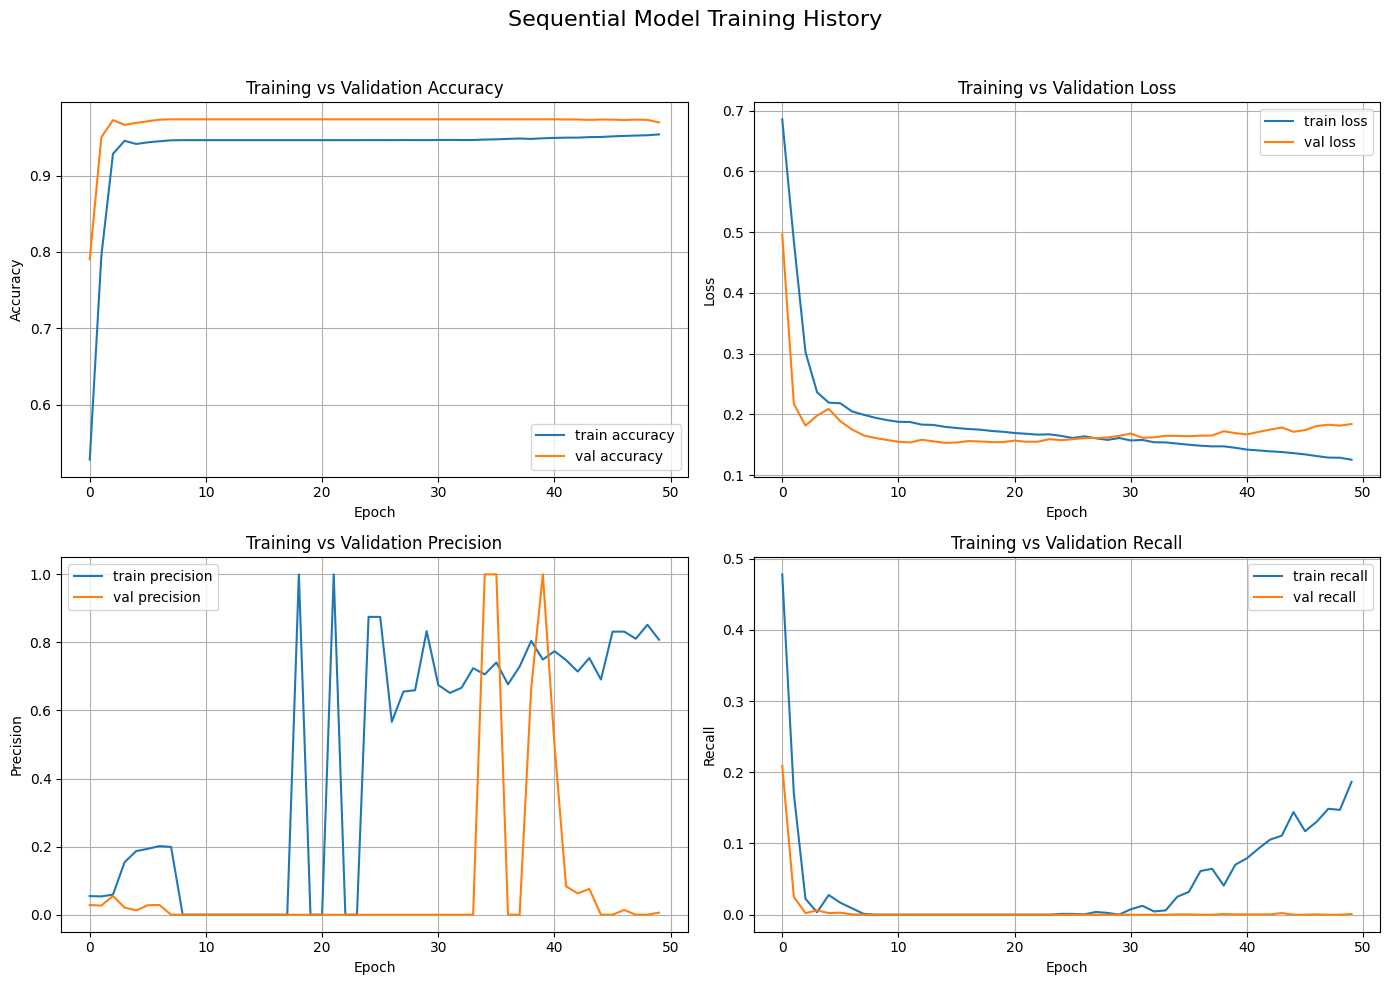

In [21]:
plot_training_history(sequential_history, title = "Sequential Model Training History")

In [22]:
seq_y_pred = sequential_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


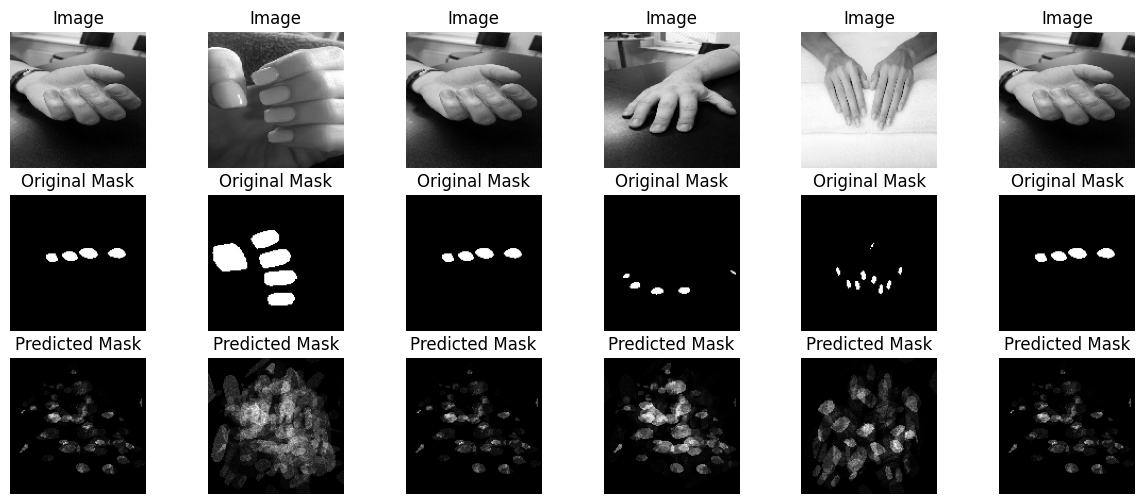

In [23]:
plot_predictions(X_test, y_test, seq_y_pred)

In [24]:
seq_results = sequential_model.evaluate(X_test, y_test, verbose=0)
metrics_names = sequential_model.metrics_names
for name, value in zip(metrics_names, seq_results):
    print(f"{name}: {value:.4f}")

loss: 0.2018
compile_metrics: 0.9533


### U-Net

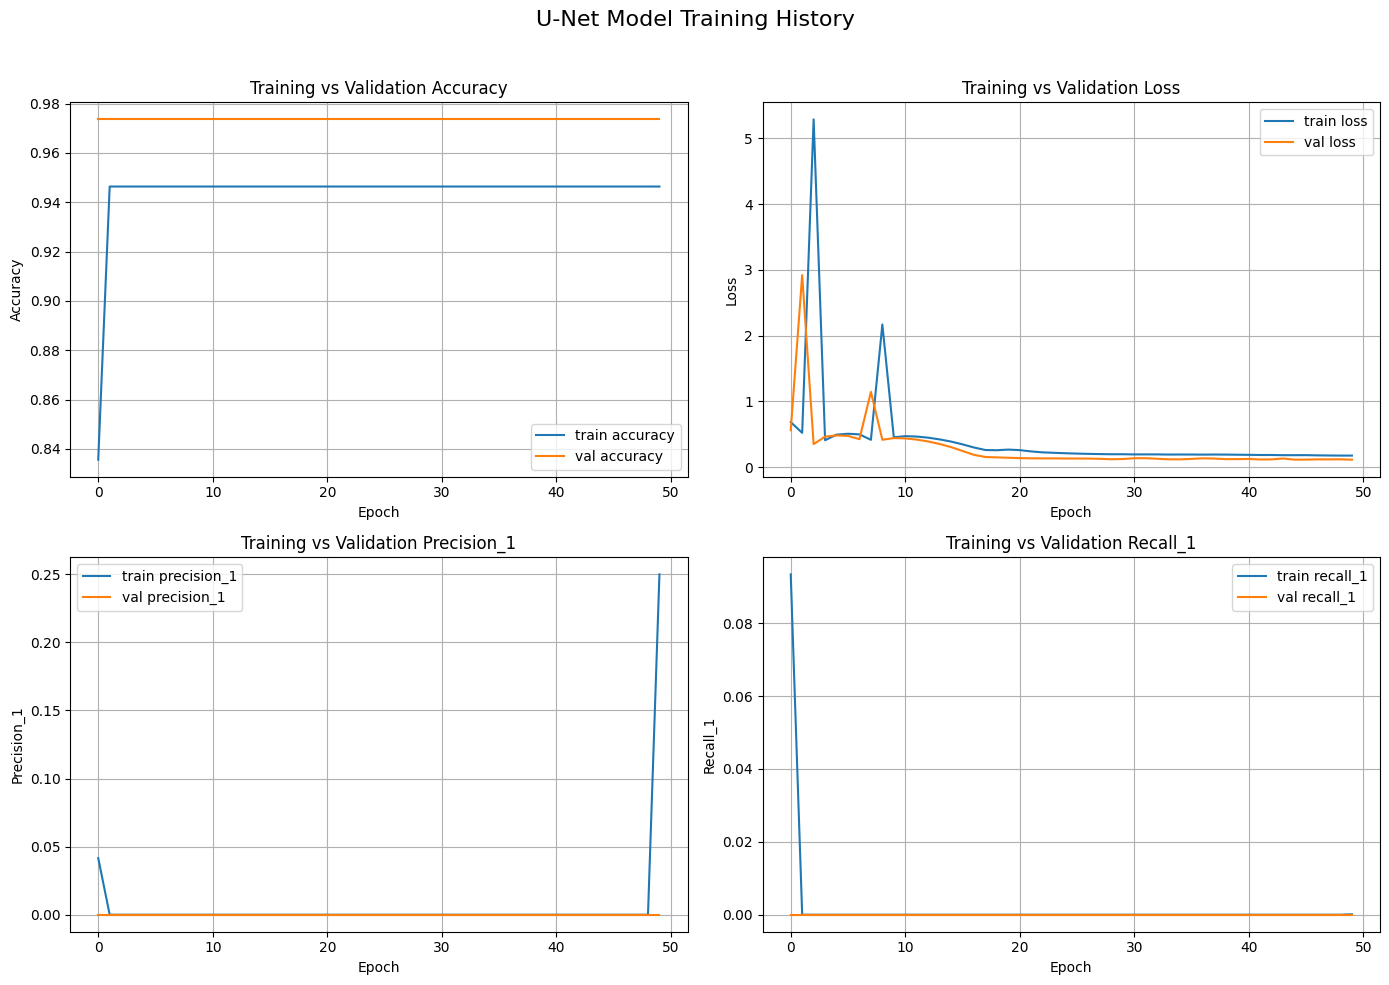

In [25]:
plot_training_history(unet_history, title = "U-Net Model Training History")

In [26]:
unet_y_pred = unet_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step


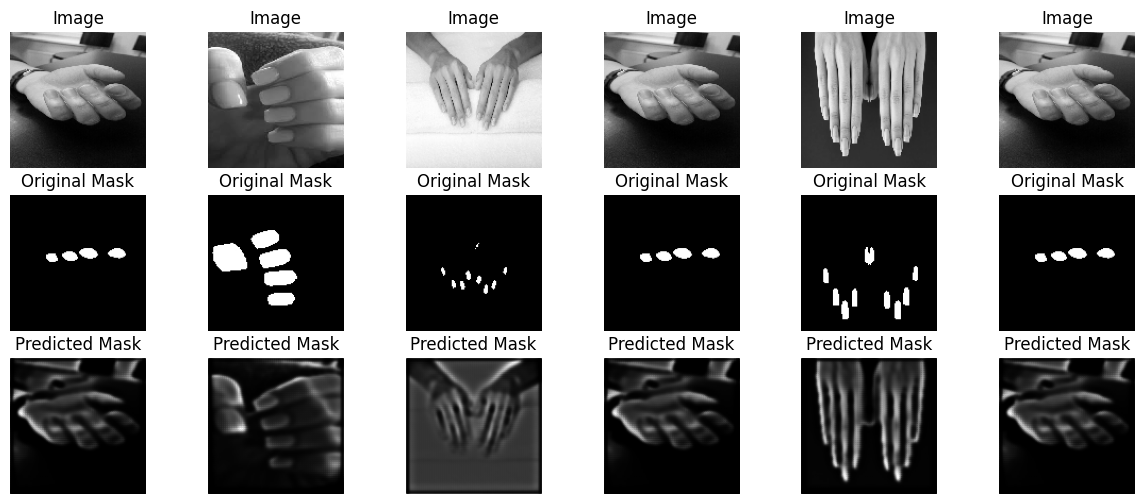

In [27]:
plot_predictions(X_test, y_test, unet_y_pred)

In [28]:
unet_results = unet_model.evaluate(X_test, y_test, verbose=0)
metrics_names = unet_model.metrics_names
for name, value in zip(metrics_names, unet_results):
    print(f"{name}: {value:.4f}")

loss: 0.1567
compile_metrics: 0.9594


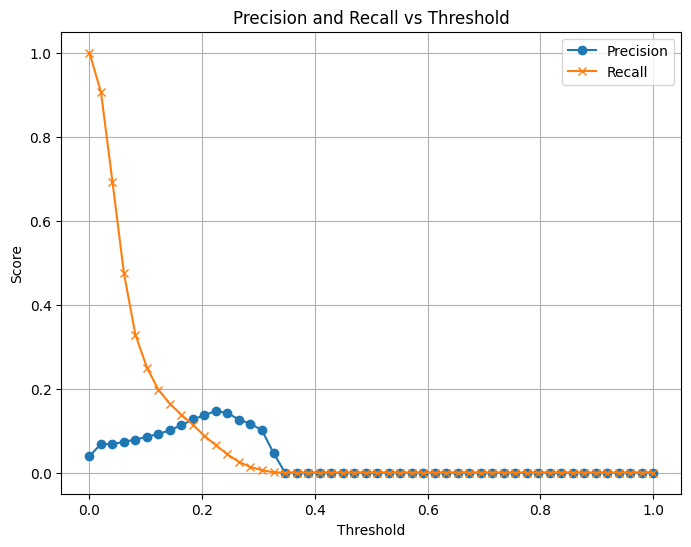

In [29]:
thresholds = np.linspace(0, 1, 50) 
precision_list = []
recall_list = []

y_test_flat = y_test.flatten().astype(int)

for t in thresholds:
    y_pred_bin = (unet_y_pred > t).astype(int)
    y_pred_flat = y_pred_bin.flatten()
    
    precision_list.append(precision_score(y_test_flat, y_pred_flat, zero_division=0))
    recall_list.append(recall_score(y_test_flat, y_pred_flat, zero_division=0))

plt.figure(figsize=(8, 6))
plt.plot(thresholds, precision_list, label='Precision', marker='o')
plt.plot(thresholds, recall_list, label='Recall', marker='x')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall vs Threshold')
plt.grid(True)
plt.legend()
plt.show()
